# Rank-2 TNMP vs BP — fully-frustrated Ising double layer

On this frustrated instance **rank-2 TNMP converges** to the correct single-site marginal while plain (single-site) **BP does not converge**.

All of the *machinery* — the model builder, double-layer factors, neighborhood / cavity construction, TreeSA planning, rank-2 message passing, the marginal, and the BP baseline — lives in **`tnmp_workflow.jl`**. This notebook is just the **example workflow**: it builds the `L = 4` model once and then *calls* into the library, printing / visualising

1. the **neighborhood** and **cavity** contents — which **tensors** and **bonds** they contain — plus a lattice **figure**;
2. the contraction **complexity** (`tc` / `sc`) and the **einsum equation** of the cavity / neighborhood sub-TNs;
3. the rank-2 **message-passing** marginal vs the **exact** marginal (and vs BP);
4. a window-size sweep tying it together.

> Requires a Julia kernel (IJulia) with the `TNMP_test` project active. Run cells top-to-bottom.

## 0. Load the workflow library + build the model

Everything below is defined in `tnmp_workflow.jl`. `build_demo_model` returns the `4×4` grid `g`, the fully-frustrated PEPS `psi`, the target `center`, and a canonical `(u, v) → edge` lookup `canon`.

In [1]:
include(joinpath(@__DIR__, "src", "tnmp_workflow.jl"))

m = build_demo_model()                 # L=4, χ=2 fully-frustrated Ising double layer
(; L, chi, seed, K, field, center, g, psi, canon) = m

println("fully-frustrated model:  L=$L  χ=$chi  K=$K  field=$field  seed=$seed")
println("grid = $L×$L  ($(length(collect(vertices(g)))) sites, $(length(collect(edges(g)))) bonds)   center = $center")

fully-frustrated model:  L=4  χ=2  K=1.0  field=0.2  seed=7


grid = 4×4  (16 sites, 24 bonds)   center = (2, 2)


### Model definition

`psi` is created by `fully_frustrated_pair_factor_state` (in `examples/double_layer_ising.jl`, pulled in by `tnmp_workflow.jl`). The single-layer amplitude $\psi(s)$ is exactly the classical Ising weight, but the double-layer object we contract, $\sum_s |\psi(s)|^2$, is *not* physical — it is a stress test where BP fails to converge while rank-2 TNMP does.

On the `L×L` grid each site carries a classical "spin" $s_v \in \{1, 2\}$ (encoding $z = -1 / +1$), and the (unnormalized) amplitude of a configuration $s$ factorizes over sites and bonds:

$$\psi(s) \;=\; \prod_{v} a(s_v)\;\prod_{e=(u,v)} K_{J_e}(s_u, s_v).$$

- **Site bias** (`field` $h = 0.2$): $a(1) = e^{-h/2},\; a(2) = e^{+h/2}$ (each site tensor is then normalized).
- **Bond / pair factor** (`K` $= 1.0$): the $2\times2$ Ising transfer matrix $K_{J}$ ($g = \tfrac{K}{2}\,J_e$) is **not stored on the edge**. We *factorize the edge tensor* as $K_{J}(s,t) = \sum_{b=1}^{\chi} F_s[b]\,F_t[b]$ ($\chi = 2$, exact) and *absorb the two half-factors into the two endpoint sites*, so the PEPS has one tensor per site and no separate edge tensors.
- **Frustration pattern**: the couplings $J_e \in \{+1, -1\}$ are assigned **deterministically** — $J_e = -1$ on vertical bonds in odd columns and $J_e = +1$ elsewhere — so every plaquette is frustrated. The `seed` does **not** randomize the couplings; it only fixes the index/tensor bookkeeping.
- **Amplitude = unnormalized classical probability**: $\psi(s) \propto e^{-E(s)}$ is the *unnormalized* classical joint probability $P(s)$ (i.e. the Boltzmann weight, before dividing by $Z$). (On AF bonds the *tensor entries* $F$ are complex, but the imaginary parts cancel in the bond sum, so each $\psi(s)$ is real and positive.)
- **Actually equivalent to a partition-function computation**: the amplitude is built at *half* strength — so $\psi(s) \propto e^{-\tfrac12 E_{K,h}(s)}$. The double layer therefore contracts $\sum_s |\psi(s)|^2 \propto \sum_s e^{-E_{K,h}(s)} = Z(K, h)$: the classical Ising partition function (Boltzmann weight) at *exactly* the printed $(K, h)$ — **not** the squared/doubled $(2K, 2h)$. The instance is still deliberately hard — fully frustrated, so single-site BP fails to converge — which is what makes it a good stress test for the message-passing schemes.

## 1. Neighborhood & cavity — contents (tensors + bonds)

We work at `region_L = 3`: a **site** gets a `3×3` window, a **bond** gets a `3×2` window. `describe_region` lists, for each region, the **sites** (each contributes a ket+bra double-layer tensor), the **internal bonds** (contracted) and the **boundary bonds** (open legs / incoming messages). Each region's **lattice figure** is drawn **directly underneath** its contents — a tensor **in the region** is a **filled** circle with **solid** bonds; a tensor **outside** is a **hollow** circle with **dashed** bonds.

> No extra VS Code / Cursor plugin is needed — only the Julia kernel with this project's `Luxor` dependency. If a figure looks blank, **restart the kernel** and re-run from the top.

### Neighborhood  R[site center]  (3×3)

neighborhood  R[site (2, 2)]  (3×3):  9 sites  ->  18 double-layer tensors (ket+bra each)
   sites          : (1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)
   internal bonds (12, contracted): (1, 1)-(2, 1), (1, 1)-(1, 2), (2, 1)-(3, 1), (2, 1)-(2, 2), (3, 1)-(3, 2), (1, 2)-(2, 2), (1, 2)-(1, 3), (2, 2)-(3, 2), (2, 2)-(2, 3), (3, 2)-(3, 3), (1, 3)-(2, 3), (2, 3)-(3, 3)
   boundary bonds (6, open / messages): (3, 1)-(4, 1), (3, 2)-(4, 2), (1, 3)-(1, 4), (2, 3)-(2, 4), (3, 3)-(4, 3), (3, 3)-(3, 4)


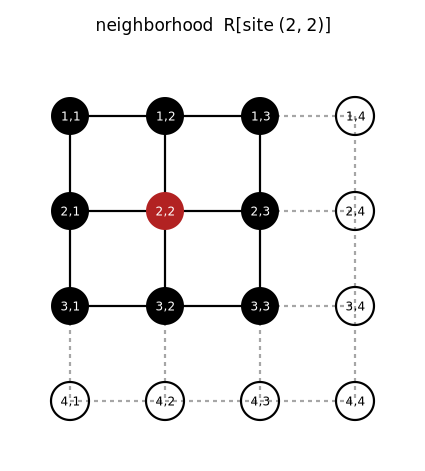

"/ssd/users/wangyijia/GTNMP/TNMP_test/demo/figures/fig_neighborhood.png"

In [2]:
regions = build_regions(g, 3)
nbhd = regions[(:site, center)]
e_in = first(boundary_edges(g, nbhd))                       # one incoming-message edge

describe_region("neighborhood  R[site $center]  (3×3)", g, nbhd)
draw_region(g, L, nbhd; center,
    title = "neighborhood  R[site $center]",
    filename = joinpath(@__DIR__, "figures", "fig_neighborhood.png"))

### Cavity  R[source] \ R[receiver]

The **cavity** of a message is the set of tensors the *source* region adds over the *receiver* region: `R[source] \ R[receiver]`. We illustrate this for the message from bond **(3,2)-(3,3)** into bond **(2,1)-(2,2)** with three lattice figures:

1. the neighborhood `R[bond (2,1)-(2,2)]` (the **receiver**), drawn entirely in **blue** — both tensors and bonds;
2. the neighborhood `R[bond (3,2)-(3,3)]` (the **source**), drawn entirely in **red**;
3. the **cavity region** `R[(3,2)-(3,3)] \ R[(2,1)-(2,2)]` that (3,2)-(3,3) passes to (2,1)-(2,2), drawn entirely in **red**.

neighborhood  R[bond (2, 1)-(2, 2)]  (3×2):  6 sites  ->  12 double-layer tensors (ket+bra each)
   sites          : (1, 1), (1, 2), (2, 1), (2, 2), (3, 1), (3, 2)
   internal bonds (7, contracted): (1, 1)-(2, 1), (1, 1)-(1, 2), (2, 1)-(3, 1), (2, 1)-(2, 2), (3, 1)-(3, 2), (1, 2)-(2, 2), (2, 2)-(3, 2)
   boundary bonds (5, open / messages): (3, 1)-(4, 1), (1, 2)-(1, 3), (2, 2)-(2, 3), (3, 2)-(4, 2), (3, 2)-(3, 3)
neighborhood  R[bond (3, 2)-(3, 3)]  (3×2):  6 sites  ->  12 double-layer tensors (ket+bra each)
   sites          : (2, 2), (2, 3), (3, 2), (3, 3), (4, 2), (4, 3)
   internal bonds (7, contracted): (2, 2)-(3, 2), (2, 2)-(2, 3), (3, 2)-(4, 2), (3, 2)-(3, 3), (4, 2)-(4, 3), (2, 3)-(3, 3), (3, 3)-(4, 3)
   boundary bonds (8, open / messages): (2, 1)-(2, 2), (3, 1)-(3, 2), (4, 1)-(4, 2), (1, 2)-(2, 2), (1, 3)-(2, 3), (2, 3)-(2, 4), (3, 3)-(3, 4), (4, 3)-(4, 4)


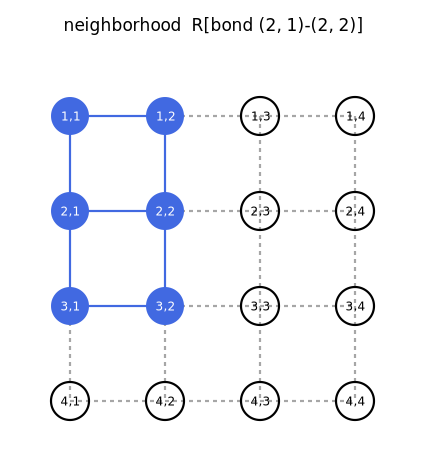

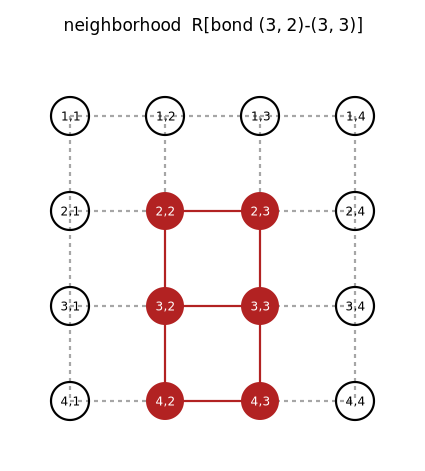

"/ssd/users/wangyijia/GTNMP/TNMP_test/demo/figures/fig_nbhd_bond_32_33.png"

In [3]:
e_a = canon[((2, 1), (2, 2))]          # receiver bond
e_b = canon[((3, 2), (3, 3))]          # source bond
nb_a = regions[(:bond, e_a)]
nb_b = regions[(:bond, e_b)]

describe_region("neighborhood  R[bond $(bond_label(e_a))]  (3×2)", g, nb_a)
draw_region(g, L, nb_a; region_color = "royalblue",
    title = "neighborhood  R[bond $(bond_label(e_a))]",
    filename = joinpath(@__DIR__, "figures", "fig_nbhd_bond_21_22.png"))

describe_region("neighborhood  R[bond $(bond_label(e_b))]  (3×2)", g, nb_b)
draw_region(g, L, nb_b; region_color = "firebrick",
    title = "neighborhood  R[bond $(bond_label(e_b))]",
    filename = joinpath(@__DIR__, "figures", "fig_nbhd_bond_32_33.png"))

cavity  R[bond (3, 2)-(3, 3)] \ R[bond (2, 1)-(2, 2)]:  4 sites  ->  8 double-layer tensors (ket+bra each)
   sites          : (2, 3), (3, 3), (4, 2), (4, 3)
   internal bonds (3, contracted): (4, 2)-(4, 3), (2, 3)-(3, 3), (3, 3)-(4, 3)
   boundary bonds (8, open / messages): (4, 1)-(4, 2), (2, 2)-(2, 3), (3, 2)-(4, 2), (3, 2)-(3, 3), (1, 3)-(2, 3), (2, 3)-(2, 4), (3, 3)-(3, 4), (4, 3)-(4, 4)


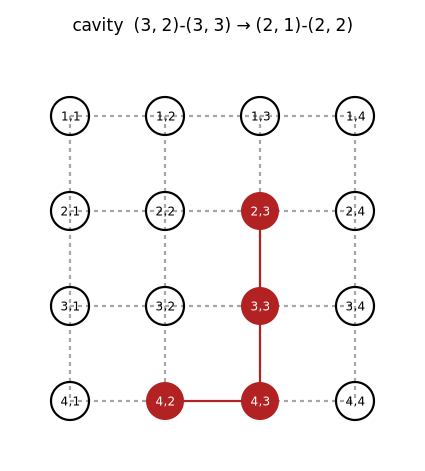

"/ssd/users/wangyijia/GTNMP/TNMP_test/demo/figures/fig_cavity_32_33_to_21_22.png"

In [4]:
cav_ba = cavity_vertices(canon, regions, (:bond, e_a), e_b)   # (3,2)-(3,3) → (2,1)-(2,2)

describe_region("cavity  R[bond $(bond_label(e_b))] \\ R[bond $(bond_label(e_a))]", g, cav_ba)
draw_region(g, L, cav_ba; region_color = "firebrick",
    title = "cavity  $(bond_label(e_b)) → $(bond_label(e_a))",
    filename = joinpath(@__DIR__, "figures", "fig_cavity_32_33_to_21_22.png"))

## 2. Contraction complexity (`tc` / `sc`) + einsum equation

`treesa_plan` finds a contraction order and reports `tc` (log2 #operations) and `sc` (log2 size of the largest intermediate). `einsum_equation` prints the contraction as a readable einsum string (each distinct tensor index → a short label; open indices form the right-hand side). We show both the **cavity** message sub-TN and the closed **neighborhood** (marginal) sub-TN.

In [5]:
messages = init_messages(psi, g, regions)

cav_ts = message_tensors(psi, g, canon, regions, messages, (:site, center), e_in)
cplan  = treesa_plan(cav_ts)
println("cavity sub-TN  ($(bond_label(e_in)) → $center):  $(length(cav_ts)) tensors")
println("   tc = $(rnd(cplan.tc))  (log2 #ops),   sc = $(rnd(cplan.sc))  (log2 max intermediate)")
println("   einsum:  ", einsum_equation(cav_ts))

nts   = neighborhood_tensors(psi, g, regions, center)
nplan = treesa_plan(nts)
println("\nneighborhood (marginal) sub-TN:  $(length(nts)) tensors")
println("   tc = $(rnd(nplan.tc)),   sc = $(rnd(nplan.sc))")
println("   einsum:  ", einsum_equation(nts))

# verify every cavity is loop-free at the graph (single-layer) level
chk = verify_cavities_acyclic(g, canon, regions, center)
println("\ncavity loop check:  $(chk.n_checked) cavities verified" *
        (chk.n_empty > 0 ? "  ($(chk.n_empty) empty, skipped)" : ""))
if chk.ok
    println("   ✓ every cavity is loop-free (single-layer induced subgraph is a forest)")
else
    println("   ✗ $(length(chk.looped)) cavities contain a loop:")
    for (node, e) in chk.looped
        println("      receiver $node  ←  in_edge $(bond_label(e))")
    end
end
@assert chk.ok "found cavity region(s) with a loop in the single-layer graph"

cavity sub-TN  ((4, 1)-(3, 1) → (2, 2)):  6 tensors
   tc = 7.0  (log2 #ops),   sc = 4.0  (log2 max intermediate)
   einsum:  abc,ade,fcgh,feij,gi,hj -> db

neighborhood (marginal) sub-TN:  24 tensors
   tc = 12.66,   sc = 8.0
   einsum:  abc,ade,fbgh,fdij,kglm,kino,pcqr,pest,hquv,jswx,ymuzaa,yowabac,adraeaf,adtagah,aivaeajak,aixagalam,anaaajaoap,anacalaqar,ln,zab,afah,akam,aoaq,apar -> 

cavity loop check:  134 cavities verified
   ✓ every cavity is loop-free (single-layer induced subgraph is a forest)


## 3. Rank-2 message passing → marginal (vs exact, vs BP)

Iterate the bond-node messages to a fixed point (rank-2 message-distance `1 - |⟨a,b⟩|²`), then close the center neighborhood to read the marginal. `exact_marginal` contracts the whole double layer with the center fixed; `bp_marginal` calls the packaged belief propagation.

In [6]:
seqs = Dict{Any, Any}()
info  = run_message_passing!(psi, g, canon, regions, messages, seqs; max_iter = 500, tol = 1e-8)
marg  = tnmp_marginal(psi, g, canon, regions, messages, seqs, center)
exact = exact_marginal(psi, g, Dict{Any, Any}(), center)
bp_marg, bp_info = bp_marginal(psi, center; maxiter = 2000, tolerance = 1e-10)

println("message passing (region_L = 3):  converged=$(info.converged)  iters=$(info.iterations)  diff=$(rnd(info.final_diff, 6))")
println("   TNMP marginal  = $(rndv(marg))   (L1 = $(rnd(l1(marg, exact), 4)))")
println("   BP   marginal  = $(rndv(bp_marg))   (L1 = $(rnd(l1(bp_marg, exact), 4)))   converged=$(bp_info.converged)")
println("   exact marginal = $(rndv(exact))")

message passing (region_L = 3):  converged=true  iters=11  diff=0.0
   TNMP marginal  = [0.1818, 0.8182]   (L1 = 0.0389)
   BP   marginal  = [0.2625, 0.7375]   (L1 = 0.2002)   converged=false
   exact marginal = [0.1624, 0.8376]


## 4. Window-size sweep

BP runs once (window-independent); rank-2 TNMP runs at `region_L = 3`.

In [7]:
println("exact marginal            = $(rndv(exact))\n")
println("method        converged  iters   marginal                  L1(.,exact)")
println("BP (1-site)   $(rpad(bp_info.converged, 9)) $(rpad(bp_info.iterations, 6))  $(rpad(rndv(bp_marg), 24))  $(rnd(l1(bp_marg, exact), 4))")
for rL in [3]
    r = tnmp_run(psi, g, canon, rL, center)
    println("$(rpad("TNMP rL=$rL", 13)) $(rpad(r.info.converged, 9)) $(rpad(r.info.iterations, 6))  $(rpad(rndv(r.marg), 24))  $(rnd(l1(r.marg, exact), 4))")
end

exact marginal            = [0.1624, 0.8376]

method        converged  iters   marginal                  L1(.,exact)
BP (1-site)   false     2000    [0.2625, 0.7375]          0.2002
TNMP rL=3     true      11      [0.1818, 0.8182]          0.0389


## Conclusion

- **BP fails to converge** (message-distance stuck at ≈ 0.53 after 2000 iters) and lands ~20% off the exact marginal.
- **Rank-2 TNMP converges** and lands much closer to the exact marginal (`L1 ≈ 0.04` at `rL = 3`, vs `≈ 0.20` for BP).
